# Moment-to-torque mapping: parameter sweeps

Sweeps for the peak-normalized power-law mapping (`scale`, `shape`, `delay`, `cap_mode`, `ceiling_mode`) vs logged `momentPredicted`. Plot functions: `exo/`.

Everything else (IMU, motor, gait cycle, load, stride-hitch, rate limit): `plot_hip_exo.ipynb`.

In [1]:
%matplotlib inline

# This machine's ipykernel doesn't auto-register matplotlib_inline's post-execute
# flush hook (plots would silently produce no output) -- register it explicitly.
from matplotlib_inline.backend_inline import flush_figures
get_ipython().events.register("post_execute", flush_figures)

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
csv_path = Path("data/pilot/2026-07-24/exo/HIP006.csv")
df = pd.read_csv(csv_path)
df.head()

In [ ]:
from exo import (
    simulate_gait_cycle,
    plot_moment_mapping_compare,
    plot_moment_mapping_scale_shape_compare,
    plot_moment_mapping_peak_invariance,
    plot_moment_mapping_delay_placement_compare,
    plot_dip_fill_compare,
    plot_moment_mapping_final_vs_recorded,
    plot_moment_mapping_rise_delay_sweep,
)

In [4]:
# istride (stride-boundary index) drives Peak-avg/Delayed-rise's peak tracking -- see
# plot_hip_exo.ipynb's "Gait cycle: MCU vs offline simulation" section for what
# simulate_gait_cycle actually does; here we only need its istride output.
# Left leg only -- moment-mapping exploration is standardized on one leg as reference.
sim_left = simulate_gait_cycle(df, "left")

## Linear vs Peak-avg torque mapping (moment_control.c)

- Linear: `torque = -scale * weight * m`
- Peak-avg: `torque = sign(-m) * scale * weight * peak * ratio^shape`
  - `ratio = min(|m|/peak, 1)` (hard cap) or `soft_cap(|m|/peak)` (soft cap, smooth approx of the min)
  - `peak` = 3-stride rolling average of that phase's (flexion/extension) peak `|m|`

Plot shows Linear vs Peak-avg (hard cap) vs Peak-avg (soft cap). Left leg only.

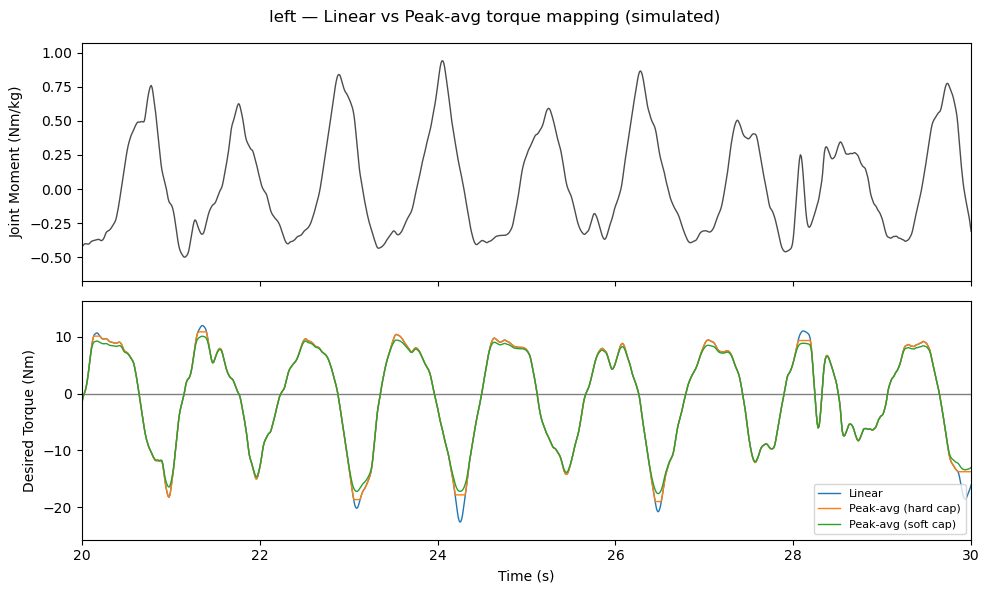

In [5]:
plot_moment_mapping_compare(df, sim_left, time_range=(20, 30));

## Linear vs Peak-avg across scale × shape

Peak-avg: `torque = sign(-m) * scale * weight * peak * min(|m|/peak, 1)^shape` (hard cap, matched ceiling — current firmware default: `scale=0.4`, `shape=1.0`)

Sweep: `scale` ∈ {0.2, 0.4} × `shape` ∈ {0.5, 2.0}, vs Linear.

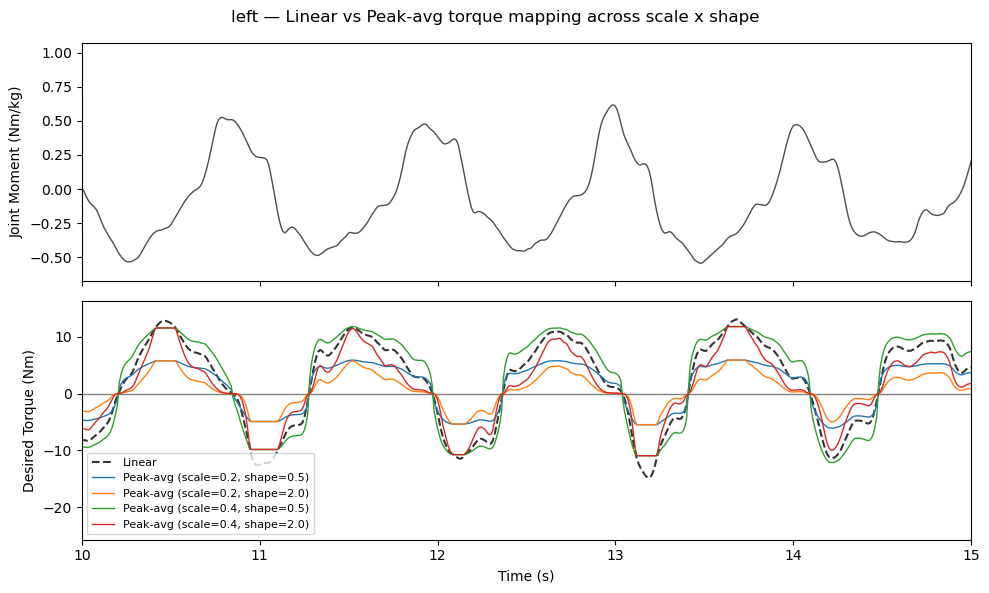

In [6]:
plot_moment_mapping_scale_shape_compare(df, sim_left, time_range=(10, 15));

## Peak-shape invariance: Peak-avg vs Delayed-rise

- Peak-avg: `torque = sign(-m) * scale * weight * peak * (|m|/peak)^shape` → peak still drifts a little with `shape`
- Delayed-rise: `torque = sign(-m) * scale * weight * min(peak_i, peak) * (|m|/peak_i)^shape` → exactly invariant to `shape` (0 Nm deviation, 190+ peaks in HIP006)
  - `peak_i` = that stride's own causal running peak (known with a small bounded delay, so `shape` affects the rise too)
  - `peak` = 3-stride rolling average (same as Peak-avg)

Top: Peak-avg (peaks fan out by shape). Bottom: Delayed-rise (peaks align, shifted later via `shift_for_delivery`).

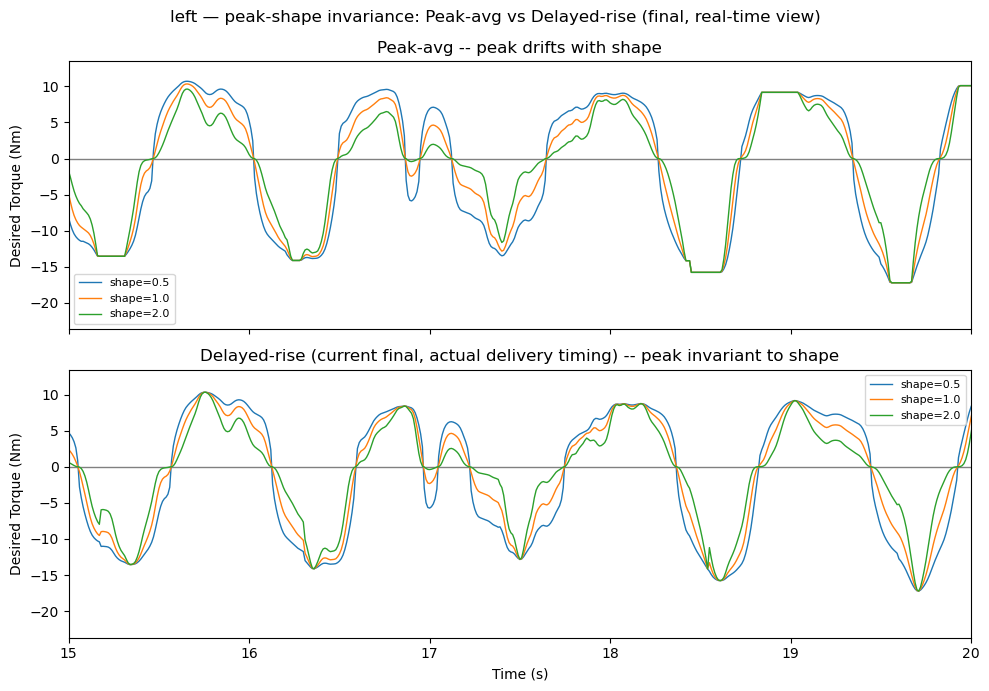

In [7]:
plot_moment_mapping_peak_invariance(df, sim_left, time_range=(15, 20), delay_ms=0, rise_delay_samples=10);

## Delayed-rise: moment-buffered vs istride-buffered, across shape

`delay_ms` (Jetson moment-estimate latency, default 200ms) needs a ring buffer somewhere
so a stale-but-just-arrived moment estimate can be matched against the right stride
context. Two places to put it:

- Moment-buffered (`simulate_delayed_rise_moment_mapping`, top): ring buffer on `m`;
  `istride` read real-time. `m` and `istride` disagree about "now" by `delay_samples`
  around every stride boundary, corrupting which stride/phase a sample gets bucketed into.
- Istride-buffered (`simulate_delayed_rise_moment_mapping_istride_buffered`, bottom): ring
  buffer on `istride` instead, so the delay_samples-old `istride` is looked up once the
  matching (already-stale) moment estimate arrives -- both describing the same real instant.

Both are explicit sample-by-sample streaming loops with real ring buffers (`collections.deque`),
matching how the actual C firmware would have to implement this -- not a numpy array-shift
trick standing in for the same numbers. Verified numerically identical to the earlier
"compute at delay_ms=0, shift the finished array" version -- except in the last ~20
samples of the recording, where the array-shift version silently discards the FIFO's
unflushed tail (`shift_for_delivery`'s truncation) while this streaming version shows it
honestly as zero. That's a real, known gap for a C port, not an artifact of this
comparison: the FIFO never empties at the end of a run, so firmware needs an explicit
flush-on-stop path to release those last samples.

Peak-shape invariance (curves converging at each stride's true peak) holds visually in
both panels, even through the first-stride transient -- the misalignment instead shows up
as a difference in absolute torque *values* right at stride boundaries (up to 6.55 Nm at
the very first stride onset in `HIP006.csv`, smaller at later transitions).

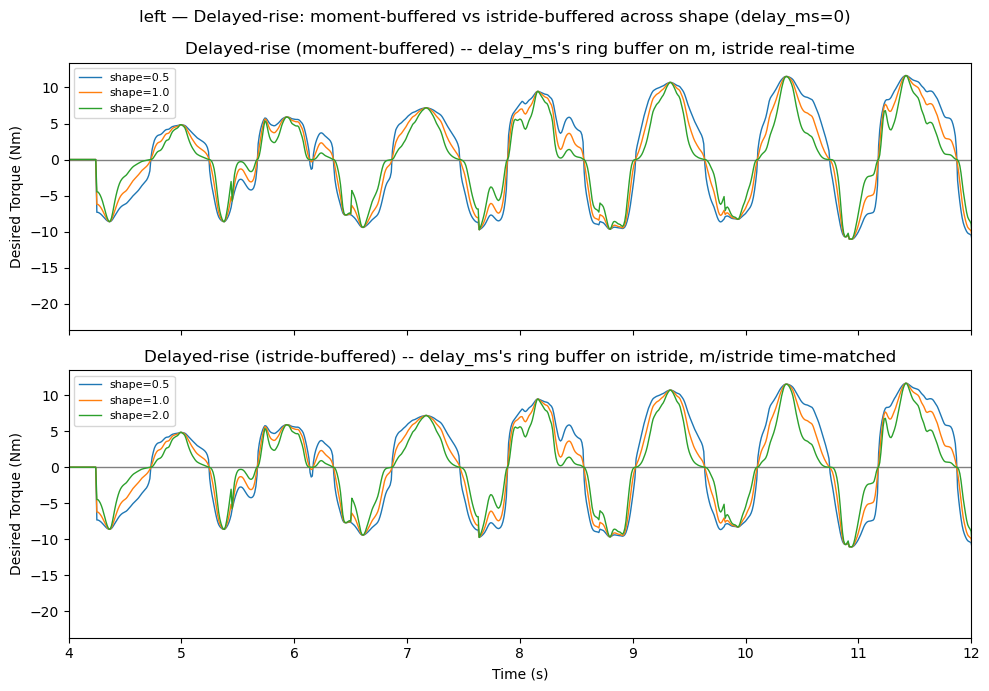

In [8]:
plot_moment_mapping_delay_placement_compare(df, sim_left, time_range=(4, 12), delay_ms = 0, rise_delay_samples=10);

## Dip-fill: removing small mid-phase "double-bump" wiggles

Some strides show a small secondary wiggle: `momentPredicted` rises toward a peak,
dips down partway, rises again to a *smaller* secondary local peak, then genuinely
declines the rest of the way to zero. `filter_dip_fill()` (`exo/dip_fill_sim.py`)
bridges exactly that kind of recoverable dip -- while leaving genuine single-peaked
strides and genuine declines untouched -- and is applied to `momentPredicted` *before*
it reaches Delayed-rise (istride-buffered).

Four independently-designed candidates (Hampel-style outlier filter, recovery-gated
taper, non-causal-oracle + bounded-causal, segment-and-merge) were built and
adversarially compared against a real HIP006-derived ground truth. The shipped design
is a hybrid: segment-and-merge's genuine-peak/prominence gate delivered via the
oracle/causal candidate's bounded 20-sample (200ms) FIFO streaming mechanism.

**Update (whole-recording gap audit)**: every remaining unfilled dip in HIP006 was
diagnosed by root cause and fixed where safe:
- **Fixed**: peak-tracking used to reset on every `istride` change, even mid-phase,
  splitting some genuine dips into two ungroupable halves -- now resets on a sign-of-
  moment change only (`istride` kept as a parameter for API parity, no longer used
  internally). Fixes 3/3 dips that were failing purely for this reason, zero side effect.
- **Fixed**: `min_seg_height` relaxed 0.035 → 0.025 (rescues a few small dips in the
  noisy pre-walk period), negligible side effect (1 sample in the whole recording).
- **Deliberately not fixed**: dips whose secondary bump recovers to only 85-89% of the
  pre-dip peak (`recover_frac` sits at 0.85) -- loosening this was tested down to 0.75
  and verified to also wrongly bridge a genuine decline-to-a-smaller-hump elsewhere
  (a ~0.19 Nm/kg error, worse than everything else measured combined). A couple of
  dips deep in the noisy post-walk tail are also left unfixed (a stale-reference-peak
  issue, confirmed *not* a window-length problem -- raising `D` up to 200 samples
  doesn't help).
- The original motivating "double-bump" examples (t≈48.15-48.9s and its lookalike at
  t≈52.69-52.90s) turned out to **not be formal dips at all** under `recover_frac=0.85`
  -- their secondary bump only reaches ~82% and ~75% of the pre-dip peak. Per this
  filter's own design intent that's a genuine decline to a smaller hump, not a
  recoverable dip, so it was never expected to be bridged.

Plot below (t=45-55s) shows one of each remaining case side by side: a flexion-phase
(`moment` positive) dip that straddled an `istride` tick, now fixed, and an extension-
phase (`moment` negative) dip at 88.6% recovery, left as a small unfilled notch by
deliberate choice.

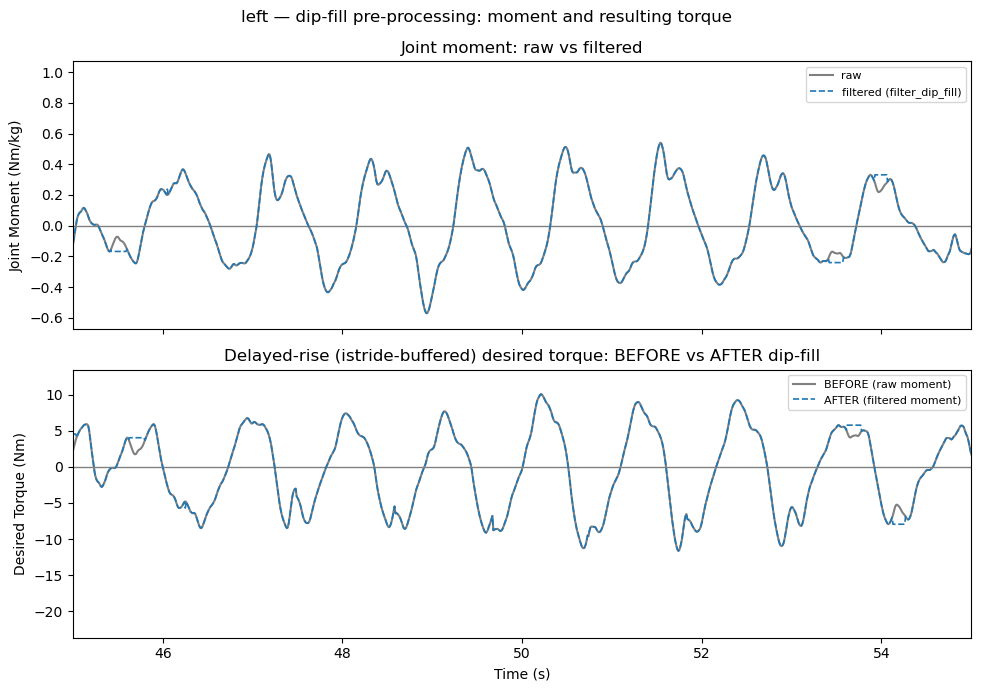

In [9]:
plot_dip_fill_compare(df, sim_left, time_range=(45, 55));

## Recorded (MCU) vs current formula

`{side}_torqueDesired` as actually logged (whatever formula was live in
`moment_control.c` when HIP006 was recorded) vs the current shipped formula
(Delayed-rise, istride-buffered: `scale=0.4`, `shape=1.0`, `delay_ms=0`,
`rise_delay_samples=15`), re-simulated from the same logged `momentPredicted`
and shown at its actual delivery timing (`shift_for_delivery`) -- i.e. what the
firmware would really command today, not a same-index comparison.

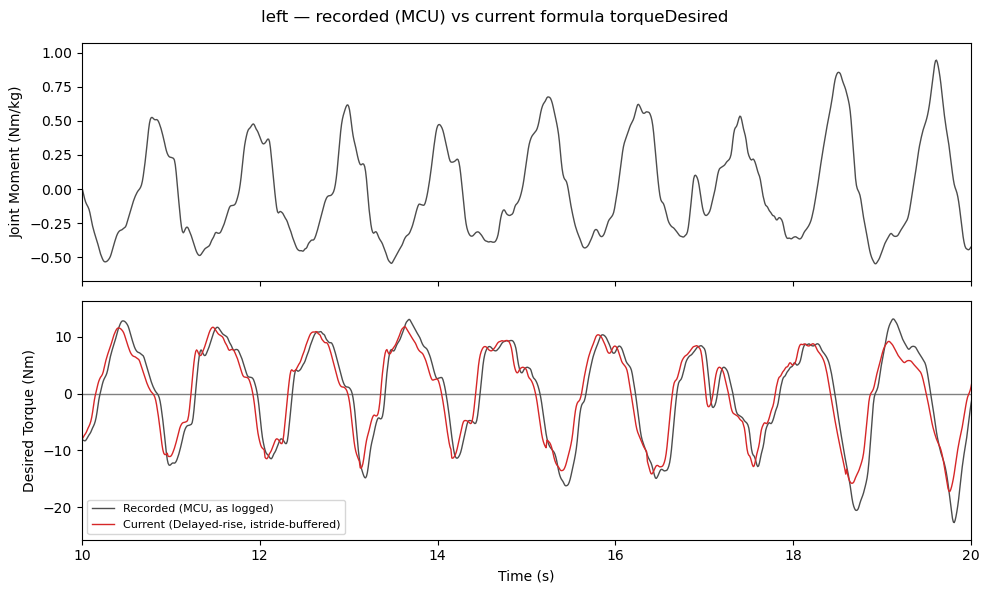

In [10]:
plot_moment_mapping_final_vs_recorded(df, sim_left, time_range=(10, 20), delay_ms=0);

## Rise-delay (K) sweep: why RISE_DELAY_SAMPLES=15

`rise_delay_samples` (K) trades added latency for how well `shape` reshapes a
stride's *rising* portion. At K=0 this is provably impossible for any causal
formula, not just this one: two strides with identical history up to sample i
but diverging only afterward are indistinguishable to a causal algorithm at i,
so making the peak exactly shape-invariant forces shape-invariance on every
candidate-peak sample -- i.e. the whole climb. A bounded extra delay is what
turns "is this the peak?" from an unobservable question into an observable one.
Larger K holds each sample longer before committing its torque, so a later,
bigger sample has more chance to correct an early guess -- but every extra
sample is extra real-time lag.

Measured on HIP006 (left leg): the "false record rate" -- how often a sample
gets confirmed as a phase's peak (releases at `local_ratio==1`) but is *later*
beaten within the same stride-phase, meaning the confirmation was premature --
drops sharply then plateaus:

| K (samples) | added latency | false records / stride |
|---|---|---|
| 0  | 0ms   | 31.71 |
| 5  | 50ms  | 0.48  |
| 10 | 100ms | 0.21  |
| 15 | 150ms | 0.15  |
| 20 | 200ms | 0.10  |
| 30 | 300ms | 0.08  |

K=15 sits at the elbow: K=0→5 captures almost all the benefit; beyond K=15,
doubling the latency again (to 30) only buys a little more (0.15→0.08). Peak
invariance itself is exact for *any* K (even 0) -- this only affects how much
of the rise gets genuinely reshaped vs. capped early.

Plot below sweeps K at `shape=2.0` (chosen to make the rise-reshaping visible --
at `shape=1` the differences are much subtler): larger K visibly smooths the
climb into each peak, while every K converges to the same value exactly at
each stride's own peak.

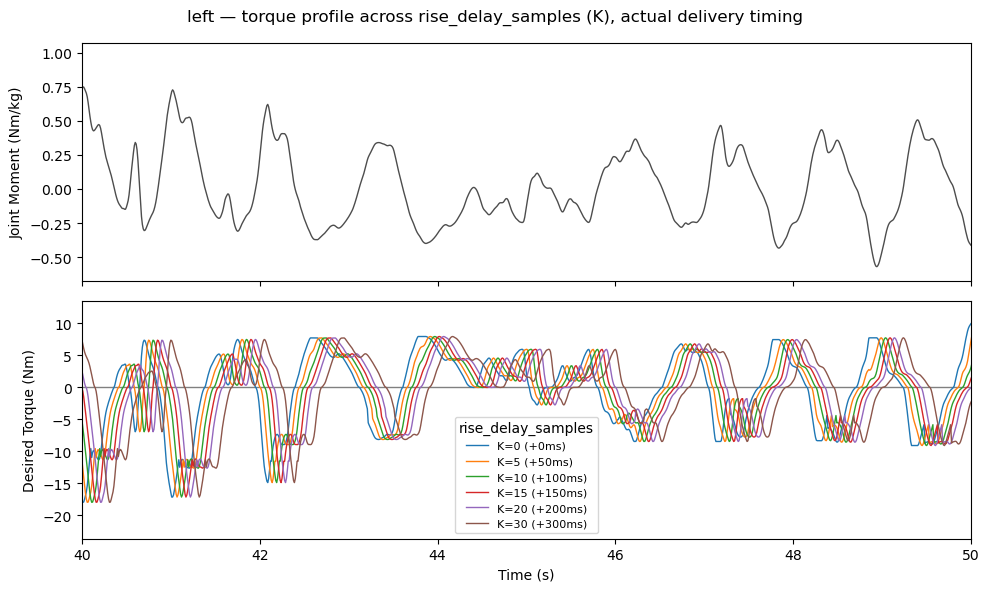

In [11]:
plot_moment_mapping_rise_delay_sweep(df, sim_left, time_range=(40, 50), shape=1.5, delay_ms=0);